<div style="
    border: 2px solid #333;
    background: #f9f9f9;
    padding: 16px 24px;
    margin: 20px 0;
    border-radius: 8px;
    font-family: sans-serif;
    overflow: hidden; /* This helps contain the floated element */
">
<div style="float: right; font-size: 12px; color: #555; text-align: right;">
    Vince Mbanze, Mmapula Kgare<br>
    15 Oct 2025
</div>
<h1 style="margin:0; color:#333; text-align:center; border-bottom: 2px solid #ccc; padding-bottom: 12px;">🧬 AMR Change Alerts for South Africa (NICD 2021–2024) 🧬</h1>
<p style="margin:16px 0 0 0; text-align: center;">
    <b>Part 1: Ingest & EB Shrinkage</b> | <b>Part 2: Adaptive Thresholds & Stability Flags</b>
</p>
<p style="margin:16px 0 0 0;">
    This notebook ingests NICD AMR CSVs, normalises provinces and counts, applies empirical-Bayes (Beta-Binomial) shrinkage to estimate reliable resistance rates per <i>province × year</i>, and learns adaptive syndrome-level thresholds (τ) to flag persistent and high-impact changes. Outputs include ranked, deduped change lists and a province-level impact chart for key bug–drug pairs.
</p>
</div>


<div style="
    border-left: 4px solid #009688;
    background: #e0f2f1;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#009688;">⚙️ 1. Data Ingest & Normalisation</h3>
  <p style="margin:12px 0 0 0;">
    Read NICD CSVs from <code>data/raw/nicd/_incoming/</code>, standardise column names, harmonise province spelling (e.g., “Kwazulu-Natal” → “KwaZulu-Natal”), and assemble a single master table with <code>organism</code>, <code>antibiotic</code>, <code>year</code>, <code>province</code>, <code>n_tested</code>, and <code>percent_resistant</code>. This ensures downstream EB and τ estimation use consistent inputs.
  </p>
</div>


In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"
OUT.mkdir(parents=True, exist_ok=True)

src = INC / "nicd_ecoli_ciprofloxacin_BLOOD_COMBINED_2021.csv"
out_path = OUT / "amr_nicd_master.csv"

# Load (handle BOM) and normalize
df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if "R" in c and "%" in c)
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip().astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

# Attach metadata from filename
tidy["organism"]   = "Escherichia coli"
tidy["antibiotic"] = "ciprofloxacin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2021

# Append (dedupe if rerun)
if out_path.exists():
    master = pd.read_csv(out_path)
    master = pd.concat([master, tidy], ignore_index=True)
    master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
else:
    master = tidy

master.to_csv(out_path, index=False)
print("Wrote:", out_path)
display(master.tail(12))


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
105,KwaZulu-Natal,7.0,41.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
106,Northern Cape,NaN,6.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
107,Western Cape,NaN,313.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
108,Western Cape,27.0,819.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
109,Northern Cape,17.0,30.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
110,North West,31.0,130.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
111,Mpumalanga,32.0,145.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
112,KwaZulu-Natal,36.0,657.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
113,Limpopo,27.0,118.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
114,Gauteng,29.0,1480.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021


In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_ecoli_ciprofloxacin_BLOOD_COMBINED_2022.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if "R" in c and "%" in c)
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip().astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)
tidy["organism"]   = "Escherichia coli"
tidy["antibiotic"] = "ciprofloxacin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2022

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master.tail(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
105,Gauteng,29.0,1480.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
106,Free State,18.0,135.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
107,Eastern Cape,27.0,407.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2021
108,Western Cape,28.0,911.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
109,Northern Cape,27.0,49.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
110,North West,33.0,124.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
111,Mpumalanga,36.0,194.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
112,KwaZulu-Natal,41.0,692.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
113,Limpopo,28.0,116.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
114,Gauteng,27.0,1572.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022


In [3]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_ecoli_ciprofloxacin_BLOOD_COMBINED_2023.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if "R" in c and "%" in c)
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip().astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)
tidy["organism"]   = "Escherichia coli"
tidy["antibiotic"] = "ciprofloxacin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2023

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master.tail(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
105,Gauteng,27.0,1572.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
106,Free State,25.0,170.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
107,Eastern Cape,33.0,421.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2022
108,Western Cape,27.0,926.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
109,Eastern Cape,34.0,443.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
110,Free State,31.0,149.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
111,Gauteng,37.0,1643.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
112,North West,32.0,212.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
113,Mpumalanga,36.0,165.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
114,Limpopo,31.0,131.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023


In [4]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_ecoli_ciprofloxacin_BLOOD_COMBINED_2024.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if "R" in c and "%" in c)
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip().astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)
tidy["organism"]   = "Escherichia coli"
tidy["antibiotic"] = "ciprofloxacin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2024

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master.tail(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
105,Limpopo,31.0,131.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
106,KwaZulu-Natal,43.0,775.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
107,Northern Cape,20.0,51.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2023
108,Western Cape,31.0,660.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
109,Eastern Cape,31.0,275.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
110,Free State,21.0,108.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
111,Gauteng,30.0,1169.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
112,North West,38.0,178.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
113,Mpumalanga,41.0,124.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024
114,Limpopo,28.0,131.0,Escherichia coli,ciprofloxacin,BLOOD,Combined,2024


In [5]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_saureus_cefoxitin_BLOOD_COMBINED_2021.csv"
master_path = OUT / "amr_nicd_master.csv"

# load (handle BOM) and pick columns robustly
df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

# clean values (keep NaNs if missing)
tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

# attach metadata
tidy["organism"]   = "Staphylococcus aureus"
tidy["antibiotic"] = "cefoxitin"    # MRSA proxy
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2021

# append & dedupe
master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Staphylococcus aureus") & master["year"].eq(2021)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,17.0,6.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
110,Free State,57.0,21.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
111,Gauteng,9.0,22.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
115,KwaZulu-Natal,NaN,4.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
114,Limpopo,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
113,Mpumalanga,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
112,North West,13.0,8.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
116,Northern Cape,29.0,17.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021
108,Western Cape,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2021


In [6]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_saureus_cefoxitin_BLOOD_COMBINED_2022.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Staphylococcus aureus"
tidy["antibiotic"] = "cefoxitin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2022

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Staphylococcus aureus") & master["year"].eq(2022)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,NaN,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
110,Free State,44.0,34.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
111,Gauteng,9.0,22.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
115,KwaZulu-Natal,NaN,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
114,Limpopo,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
113,Mpumalanga,NaN,5.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
112,North West,NaN,6.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
116,Northern Cape,NaN,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022
108,Western Cape,100.0,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2022


In [7]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_saureus_cefoxitin_BLOOD_COMBINED_2023.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Staphylococcus aureus"
tidy["antibiotic"] = "cefoxitin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2023

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Staphylococcus aureus") & master["year"].eq(2023)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,NaN,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
110,Free State,44.0,27.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
111,Gauteng,17.0,18.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
115,KwaZulu-Natal,NaN,3.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
114,Limpopo,50.0,2.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
113,Mpumalanga,33.0,3.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
112,North West,NaN,3.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
116,Northern Cape,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023
108,Western Cape,25.0,4.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2023


In [8]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_saureus_cefoxitin_BLOOD_COMBINED_2024.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Staphylococcus aureus"
tidy["antibiotic"] = "cefoxitin"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2024

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Staphylococcus aureus") & master["year"].eq(2024)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,NaN,2.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
110,Free State,21.0,14.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
111,Gauteng,NaN,25.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
115,KwaZulu-Natal,50.0,2.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
114,Limpopo,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
113,Mpumalanga,100.0,2.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
112,North West,NaN,1.0,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
116,Northern Cape,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024
108,Western Cape,NaN,NaN,Staphylococcus aureus,cefoxitin,BLOOD,Combined,2024


In [9]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_spneumoniae_penicillin_BLOOD_COMBINED_2021.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Streptococcus pneumoniae"
tidy["antibiotic"] = "penicillin (non-CNS)"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2021

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Streptococcus pneumoniae") & master["year"].eq(2021)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,1.0,75.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
110,Free State,NaN,8.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
111,Gauteng,4.0,219.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
115,KwaZulu-Natal,7.0,41.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
114,Limpopo,11.0,9.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
113,Mpumalanga,NaN,10.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
112,North West,5.0,19.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
116,Northern Cape,NaN,6.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021
108,Western Cape,NaN,313.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2021


In [10]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_spneumoniae_penicillin_BLOOD_COMBINED_2022.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Streptococcus pneumoniae"
tidy["antibiotic"] = "penicillin (non-CNS)"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2022

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Streptococcus pneumoniae") & master["year"].eq(2022)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,2.0,131.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
110,Free State,NaN,15.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
111,Gauteng,5.0,257.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
115,KwaZulu-Natal,4.0,72.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
114,Limpopo,NaN,11.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
113,Mpumalanga,3.0,35.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
112,North West,23.0,13.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
116,Northern Cape,14.0,7.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022
108,Western Cape,1.0,516.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2022


In [11]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_spneumoniae_penicillin_BLOOD_COMBINED_2023.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Streptococcus pneumoniae"
tidy["antibiotic"] = "penicillin (non-CNS)"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2023

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Streptococcus pneumoniae") & master["year"].eq(2023)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,3.0,116.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
108,Free State,6.0,16.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
110,Gauteng,8.0,221.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
114,KwaZulu-Natal,2.0,48.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
113,Limpopo,NaN,13.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
112,Mpumalanga,8.0,12.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
111,North West,24.0,17.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
115,Northern Cape,11.0,9.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023
116,Western Cape,0.0,415.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2023


In [12]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
INC  = ROOT / "data" / "raw" / "nicd" / "_incoming"
OUT  = ROOT / "data" / "raw" / "nicd"

src = INC / "nicd_spneumoniae_penicillin_BLOOD_COMBINED_2024.csv"
master_path = OUT / "amr_nicd_master.csv"

df = pd.read_csv(src, encoding="utf-8-sig")
prov_col = next(c for c in df.columns if c.strip().lower().startswith("province"))
r_col    = next(c for c in df.columns if ("R" in c and "%" in c))
n_col    = next(c for c in df.columns if "total" in c.lower() and "tested" in c.lower())

tidy = (df.rename(columns={prov_col:"province", r_col:"percent_resistant", n_col:"n_tested"})
          [["province","percent_resistant","n_tested"]].copy())

tidy["percent_resistant"] = (
    tidy["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    .replace({"": None}).astype(float)
)
tidy["province"] = (
    tidy["province"].astype(str).str.strip().str.title()
    .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West","Nothern Cape":"Northern Cape"})
)

tidy["organism"]   = "Streptococcus pneumoniae"
tidy["antibiotic"] = "penicillin (non-CNS)"
tidy["specimen"]   = "BLOOD"
tidy["sector"]     = "Combined"
tidy["year"]       = 2024

master = pd.read_csv(master_path)
master = pd.concat([master, tidy], ignore_index=True)
master = master.drop_duplicates(subset=["province","organism","antibiotic","specimen","sector","year"], keep="last")
master.to_csv(master_path, index=False)
print("Wrote:", master_path)
master[master["organism"].eq("Streptococcus pneumoniae") & master["year"].eq(2024)].sort_values("province").head(12)


Wrote: /workspace/data/raw/nicd/amr_nicd_master.csv


,province,percent_resistant,n_tested,organism,antibiotic,specimen,sector,year
109,Eastern Cape,1.0,75.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
108,Free State,NaN,8.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
110,Gauteng,4.0,219.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
114,KwaZulu-Natal,7.0,41.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
113,Limpopo,11.0,9.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
112,Mpumalanga,NaN,10.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
111,North West,5.0,19.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
115,Northern Cape,NaN,6.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024
116,Western Cape,NaN,313.0,Streptococcus pneumoniae,penicillin (non-CNS),BLOOD,Combined,2024


In [13]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
MASTER = ROOT / "data" / "raw" / "nicd" / "amr_nicd_master.csv"
OUTDIR = ROOT / "outputs" / "tables"
OUTDIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MASTER)

# keep only the three organism–antibiotic pairs we collected
keep = [
    ("Escherichia coli","ciprofloxacin"),
    ("Staphylococcus aureus","cefoxitin"),
    ("Streptococcus pneumoniae","penicillin (non-CNS)"),
]
df = df[df.set_index(["organism","antibiotic"]).index.isin(keep)].copy()

# tidy types and sort
df["n_tested"] = pd.to_numeric(df["n_tested"], errors="coerce")
df["percent_resistant"] = pd.to_numeric(df["percent_resistant"], errors="coerce")
df = df.sort_values(["organism","antibiotic","year","province"])

# write a flat overview
overview_path = OUTDIR / "amr_blood_overview.csv"
df.to_csv(overview_path, index=False)

# quick sanity: coverage by year
coverage = (df
    .groupby(["organism","antibiotic","year"])
    .agg(provinces=("province","nunique"),
         total_tests=("n_tested","sum"),
         med_R_pct=("percent_resistant","median"))
    .reset_index()
    .sort_values(["organism","antibiotic","year"])
)
display(coverage)

print("Wrote:", overview_path)


,organism,antibiotic,year,provinces,total_tests,med_R_pct
0,Escherichia coli,ciprofloxacin,2021,9,3921.0,27.0
1,Escherichia coli,ciprofloxacin,2022,9,4249.0,28.0
2,Escherichia coli,ciprofloxacin,2023,9,4495.0,32.0
3,Escherichia coli,ciprofloxacin,2024,9,3185.0,31.0
4,Staphylococcus aureus,cefoxitin,2021,9,78.0,17.0
5,Staphylococcus aureus,cefoxitin,2022,9,71.0,44.0
6,Staphylococcus aureus,cefoxitin,2023,9,61.0,33.0
7,Staphylococcus aureus,cefoxitin,2024,9,46.0,50.0
8,Streptococcus pneumoniae,penicillin (non-CNS),2021,9,700.0,5.0
9,Streptococcus pneumoniae,penicillin (non-CNS),2022,9,1057.0,4.0


Wrote: /workspace/outputs/tables/amr_blood_overview.csv


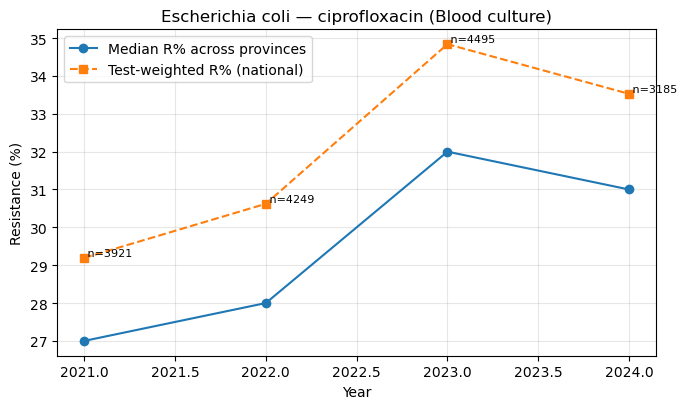

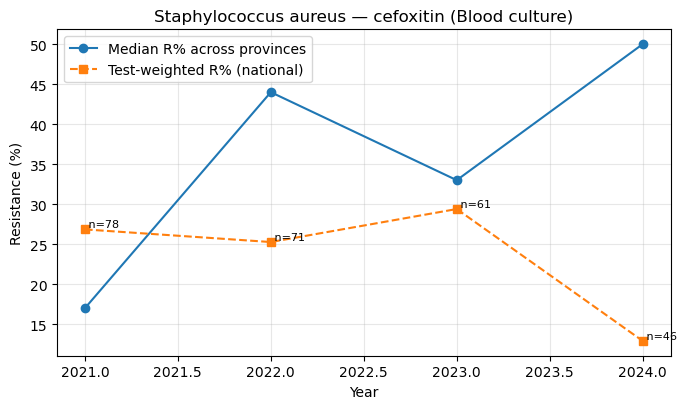

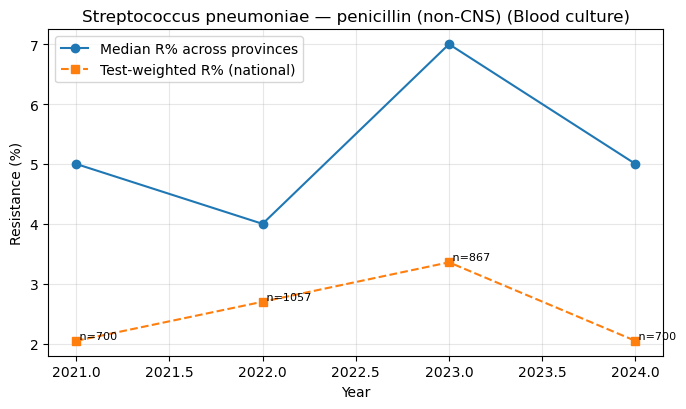

Wrote figures:
 - /workspace/outputs/figures/trend_Escherichia_coli_ciprofloxacin.png
 - /workspace/outputs/figures/trend_Staphylococcus_aureus_cefoxitin.png
 - /workspace/outputs/figures/trend_Streptococcus_pneumoniae_penicillin_non-CNS.png


In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT   = Path("/workspace")
MASTER = ROOT / "data" / "raw" / "nicd" / "amr_nicd_master.csv"
FIGDIR = ROOT / "outputs" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- load & keep only our 3 organism–antibiotic pairs ---
df = pd.read_csv(MASTER)
pairs = [
    ("Escherichia coli", "ciprofloxacin"),
    ("Staphylococcus aureus", "cefoxitin"),
    ("Streptococcus pneumoniae", "penicillin (non-CNS)"),
]
df = df[df.set_index(["organism", "antibiotic"]).index.isin(pairs)].copy()
df["n_tested"] = pd.to_numeric(df["n_tested"], errors="coerce")
df["percent_resistant"] = pd.to_numeric(df["percent_resistant"], errors="coerce")

def make_trend(one_org: str, one_abx: str) -> Path:
    sub = df[(df["organism"] == one_org) & (df["antibiotic"] == one_abx)].copy()

    # --- robust, warning-free aggregations ---
    # median by year
    med = (
        sub.groupby("year", dropna=False)["percent_resistant"]
        .median()
        .rename("median_R")
    )

    # weighted by year: sum(R% * n) / sum(n) without apply
    w = (
        sub.assign(_wprod=sub["percent_resistant"] * sub["n_tested"])
           .groupby("year", dropna=False)
           .agg(weighted_sum=("_wprod", "sum"),
                total_tests=("n_tested", "sum"))
    )
    # avoid divide-by-zero; keep NaN if total_tests is 0/NaN
    w["weighted_R"] = np.where(
        w["total_tests"].fillna(0) > 0,
        w["weighted_sum"] / w["total_tests"],
        np.nan
    )

    # merge into one frame for plotting
    g = med.to_frame().join(w[["weighted_R", "total_tests"]]).reset_index()

    # --- plot ---
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(g["year"], g["median_R"], marker="o", label="Median R% across provinces")
    ax.plot(g["year"], g["weighted_R"], marker="s", linestyle="--",
            label="Test-weighted R% (national)")
    ax.set_title(f"{one_org} — {one_abx} (Blood culture)")
    ax.set_xlabel("Year"); ax.set_ylabel("Resistance (%)")
    ax.grid(True, alpha=0.3); ax.legend()

    # annotate total n on the weighted series
    for (_, r) in g.iterrows():
        ax.text(r["year"], r["weighted_R"], f" n={int(r['total_tests']) if pd.notna(r['total_tests']) else 0}",
                fontsize=8, ha="left", va="bottom")

    fig.tight_layout()

    # save
    safe = f"trend_{one_org}_{one_abx}".replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    outpath = FIGDIR / f"{safe}.png"
    fig.savefig(outpath, dpi=150)
    plt.show()
    plt.close(fig)
    return outpath

# run for the three pairs
outs = []
for org, abx in pairs:
    outs.append(make_trend(org, abx))

print("Wrote figures:")
for p in outs:
    print(" -", p)


     province  R_percent      n
 Eastern Cape       34.0  443.0
   Free State       31.0  149.0
      Gauteng       37.0 1643.0
KwaZulu-Natal       43.0  775.0
      Limpopo       31.0  131.0
   Mpumalanga       36.0  165.0
   North West       32.0  212.0
Northern Cape       20.0   51.0
 Western Cape       27.0  926.0


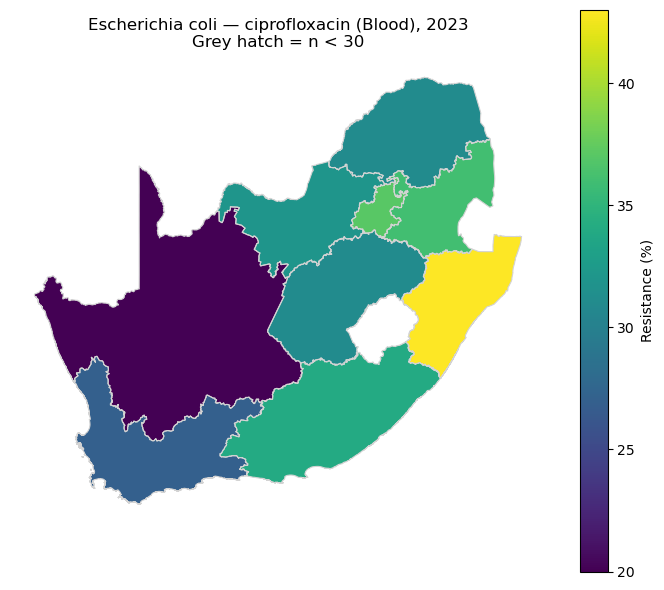

In [15]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT   = Path("/workspace")
MASTER = ROOT / "data" / "raw" / "nicd" / "amr_nicd_master.csv"
GEO    = ROOT / "data" / "raw" / "provinces.geojson"

# ---- choose the slice ----
YEAR = 2023
ORG  = "Escherichia coli"
ABX  = "ciprofloxacin"
N_MIN = 30
# --------------------------

# load data
df = pd.read_csv(MASTER)
df["n_tested"] = pd.to_numeric(df["n_tested"], errors="coerce")
df["percent_resistant"] = pd.to_numeric(df["percent_resistant"], errors="coerce")

sub = df[
    (df["organism"] == ORG) &
    (df["antibiotic"] == ABX) &
    (df["year"] == YEAR) &
    (df["specimen"].str.upper() == "BLOOD") &
    (df["sector"].str.lower() == "combined")
].copy()

# standardize province names for join
fix = {"Kwazulu-Natal": "KwaZulu-Natal", "Northern cape": "Northern Cape", "North west": "North West"}
sub["province_std"] = sub["province"].str.title().replace(fix)

gdf = gpd.read_file(GEO)
gdf["province_std"] = gdf["province"].astype(str)

merged = gdf.merge(
    sub[["province_std", "percent_resistant", "n_tested"]],
    on="province_std", how="left"
)

# table above map
disp = (sub.sort_values("province")
          .rename(columns={"percent_resistant": "R_percent", "n_tested": "n"})
          [["province","R_percent","n"]])
print(disp.to_string(index=False))

# plotting helpers
def safe_plot(gdf_part, *args, **kwargs):
    """Plot only if the slice is non-empty and has finite bounds."""
    if gdf_part is None or len(gdf_part) == 0:
        return
    # GeoPandas can still choke if total_bounds are nan
    if not pd.isna(gdf_part.total_bounds).any():
        gdf_part.plot(*args, **kwargs)

fig, ax = plt.subplots(figsize=(7, 6))

# base boundary
safe_plot(gdf.boundary, ax=ax, linewidth=0.8, color="lightgrey")
ax.set_aspect("equal")

# provinces with sufficient n
mask_ok = (merged["n_tested"] >= N_MIN) & merged["percent_resistant"].notna()
safe_plot(
    merged.loc[mask_ok],
    column="percent_resistant", ax=ax, cmap="viridis", legend=True,
    legend_kwds={"label": "Resistance (%)"}
)

# shade low-n provinces
mask_low = (merged["n_tested"] < N_MIN) & merged["n_tested"].notna()
safe_plot(
    merged.loc[mask_low],
    ax=ax, color="lightgrey", alpha=0.6, hatch="//", edgecolor="grey"
)

ax.set_title(f"{ORG} — {ABX} (Blood), {YEAR}\nGrey hatch = n < {N_MIN}")
ax.axis("off")
plt.tight_layout()
plt.show()


<div style="
    border-left: 4px solid #f44336;
    background: #ffebee;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#f44336;">💾 2. Empirical-Bayes (Beta-Binomial) Estimates</h3>
  <p style="margin:12px 0 0 0;">
    Convert <code>percent_resistant</code> and <code>n_tested</code> to counts (<code>r_count</code>, <code>s_count</code>), fit a Beta prior, and compute shrunken means <code>eb_theta</code> with credible intervals. We also label confidence by CI width. This reduces variance in small-n provinces and stabilises year-to-year comparisons.
  </p>
</div>


In [16]:
# --- MODULE 1: EB shrinkage + mismatch probability ---------------------------
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import beta

ROOT   = Path("/workspace")
MASTER = ROOT / "data" / "raw" / "nicd" / "amr_nicd_master.csv"
PROV   = ROOT / "data" / "raw" / "provinces.geojson"   # your saved admin-1 GeoJSON
OUTT   = ROOT / "outputs" / "tables"
OUTT.mkdir(parents=True, exist_ok=True)

# ---- load & clean
df = pd.read_csv(MASTER).copy()
df["n_tested"]          = pd.to_numeric(df["n_tested"], errors="coerce")
df["percent_resistant"] = pd.to_numeric(df["percent_resistant"], errors="coerce")

# reconstruct integer resistant counts (keep NaN if either piece is NaN)
df["r_count"] = np.where(
    df["n_tested"].notna() & df["percent_resistant"].notna(),
    np.rint(df["percent_resistant"] / 100.0 * df["n_tested"]).astype("Int64"),
    pd.Series([pd.NA]*len(df), dtype="Int64")
)

# guard rails
df.loc[df["r_count"] < 0, "r_count"] = 0
df.loc[df["r_count"] > df["n_tested"], "r_count"] = df.loc[df["r_count"] > df["n_tested"], "n_tested"].astype("Int64")

# ---- adaptive thresholds (override per pair here if you want)
# default τ = 0.20; you can put custom values per pair into this dict
TAU_DEFAULT = 0.20
TAU_BY_PAIR = {
    # ("Streptococcus pneumoniae", "penicillin (non-CNS)"): 0.10,
    # ("Staphylococcus aureus", "cefoxitin"): 0.20,
    # ("Escherichia coli", "ciprofloxacin"): 0.20,
}

def pick_tau(org, abx):
    return TAU_BY_PAIR.get((org, abx), TAU_DEFAULT)

# ---- build national priors per (organism, antibiotic, year)
grp_keys = ["organism", "antibiotic", "year"]

nat = (
    df.dropna(subset=["n_tested", "r_count"])
      .groupby(grp_keys, dropna=False)
      .agg(national_r=("r_count","sum"),
           national_n=("n_tested","sum"))
      .reset_index()
)
nat["national_s"] = nat["national_n"] - nat["national_r"]

# Beta prior parameters (from national counts). Add small prior mass to avoid 0/0.
# Jeffreys-like pseudo-counts: +0.5 on each side (you can change to +1 if you prefer).
nat["alpha0"] = nat["national_r"] + 0.5
nat["beta0"]  = nat["national_s"] + 0.5

df = df.merge(nat[grp_keys+["alpha0","beta0"]], on=grp_keys, how="left")

# ---- EB posterior + Jeffreys CI + mismatch probability P(theta > tau)
def post_params(r, n, a0, b0):
    return (r + a0, (n - r) + b0)

def jeffreys_ci(r, n, level=0.95):
    if pd.isna(r) or pd.isna(n) or n <= 0:
        return (np.nan, np.nan)
    a = r + 0.5
    b = (n - r) + 0.5
    lo = beta.ppf((1-level)/2, a, b)
    hi = beta.ppf(1 - (1-level)/2, a, b)
    return (float(lo), float(hi))

def eb_mean(r, n, a0, b0):
    if pd.isna(r) or pd.isna(n) or pd.isna(a0) or pd.isna(b0) or (n + a0 + b0) <= 0:
        return np.nan
    return (r + a0) / (n + a0 + b0)

def mismatch_prob(r, n, a0, b0, tau):
    if any(pd.isna(x) for x in (r,n,a0,b0)) or n <= 0:
        return np.nan
    a_post, b_post = post_params(r, n, a0, b0)
    return 1.0 - beta.cdf(tau, a_post, b_post)

# vectorized compute
rows = []
for idx, row in df.iterrows():
    r = row["r_count"]
    n = row["n_tested"]
    a0, b0 = row["alpha0"], row["beta0"]
    org, abx = row["organism"], row["antibiotic"]
    tau = pick_tau(org, abx)

    eb   = eb_mean(r, n, a0, b0)
    lo, hi = jeffreys_ci(r, n)
    mp   = mismatch_prob(r, n, a0, b0, tau)

    rows.append((eb, lo, hi, mp, tau))

df[["eb_theta","ci_lo","ci_hi","mismatch_prob","tau_used"]] = pd.DataFrame(rows, index=df.index)

# confidence band from CI width
def conf_badge(lo, hi):
    if pd.isna(lo) or pd.isna(hi):
        return "unknown"
    w = hi - lo
    if w < 0.10: return "high"
    if w < 0.20: return "medium"
    return "low"

df["confidence"] = [conf_badge(lo, hi) for lo,hi in zip(df["ci_lo"], df["ci_hi"])]

# ---- save
out_cols = [
    "province","organism","antibiotic","year","specimen","sector",
    "n_tested","percent_resistant","r_count",
    "alpha0","beta0","eb_theta","ci_lo","ci_hi","tau_used","mismatch_prob","confidence"
]
scores_path = OUTT / "scores_eb.csv"
df[out_cols].to_csv(scores_path, index=False)
print("Wrote:", scores_path)

# ---- (optional) quick map helper for any pair+year shaded by mismatch_prob
import geopandas as gpd
import matplotlib.pyplot as plt

G = gpd.read_file(PROV)
G["province_std"] = G["province"].astype(str)

def show_mismatch_map(org, abx, year, n_min=30):
    sub = df[(df["organism"]==org) & (df["antibiotic"]==abx) & (df["year"]==year)].copy()
    # standardize province names (already in title case in your pipeline; adjust if needed)
    fix = {"Kwazulu-Natal":"KwaZulu-Natal", "Northern cape":"Northern Cape", "North west":"North West"}
    sub["province_std"] = sub["province"].str.title().replace(fix)

    M = G.merge(sub, on="province_std", how="left")
    fig, ax = plt.subplots(figsize=(7,6))
    # base
    G.boundary.plot(ax=ax, color="lightgrey", linewidth=0.8)
    # main fill: provinces meeting n_min
    ok = (M["n_tested"] >= n_min) & M["mismatch_prob"].notna()
    M.loc[ok].plot(column="mismatch_prob", ax=ax, legend=True, cmap="magma",
                   legend_kwds={"label":"P(θ > τ)"})
    # hatch low-n
    low = (M["n_tested"] < n_min) & M["n_tested"].notna()
    if low.any():
        M.loc[low].plot(ax=ax, color="lightgrey", alpha=0.6, hatch="//", edgecolor="grey")
    ax.set_title(f"{org} — {abx} (Blood), {year}\nShading = mismatch probability; hatch = n<{n_min}")
    ax.axis("off"); plt.tight_layout(); plt.show()

# Example (uncomment to preview):
# show_mismatch_map("Escherichia coli", "ciprofloxacin", 2023, n_min=30)


Wrote: /workspace/outputs/tables/scores_eb.csv


<div style="
    border-left: 4px solid #f44336;
    background: #ffebee;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#f44336;">💾 4. Stability & Change Detection</h3>
  <p style="margin:12px 0 0 0;">
    Flag <b>stable alerts</b> when <code>eb_theta ≥ τ</code> for <b>K = 2</b> consecutive years and/or when the rolling slope over a 3-year window is ≥ 0.05/year. Compute an impact proxy
    <code>impact_per_1000_tests = 1000 * max(eb_theta − τ, 0)</code>, dedupe to the most recent year per bug–drug, require <code>n_tested ≥ 30</code>, and keep only positive-impact rows. Output: <code>change_list.csv</code> → <code>change_list_clean.csv</code> → <code>change_list_actionable.csv</code>.
  </p>
</div>


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/workspace")
IN   = ROOT / "outputs" / "tables" / "scores_eb.csv"
OUT  = ROOT / "outputs" / "tables" / "stability_flags.csv"

# hyper-params
P_STAR = 0.80   # require Pr(θ>τ) above this…
K_CONS = 2      # …for k consecutive years
SLOPE_WINDOW = 3
SLOPE_MIN = 0.05   # per year increase in EB mean to count as “worsening”

df = pd.read_csv(IN)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.sort_values(["organism","antibiotic","province","year"])

def _stable_flag(g):
    """Return a DataFrame with stability flags for a province×pair across years."""
    g = g.copy()
    prob = g["mismatch_prob"].fillna(0.0).values
    # k-consecutive above p*
    run = (prob > P_STAR).astype(int)
    kroll = pd.Series(run).rolling(K_CONS).sum().fillna(0).values
    cons_flag = (kroll >= K_CONS)
    # slope on EB mean (last SLOPE_WINDOW or all if shorter)
    eb = g["eb_theta"].astype(float).values
    slope_flag = np.zeros(len(g), dtype=bool)
    for i in range(len(g)):
        start = max(0, i - (SLOPE_WINDOW - 1))
        xs = g["year"].values[start:i+1]
        ys = eb[start:i+1]
        if len(xs) >= 2 and np.isfinite(ys).sum() >= 2:
            # simple least-squares slope per year
            m, b = np.polyfit(xs, ys, 1)
            slope_flag[i] = (m >= SLOPE_MIN)
    g["stable_alert"] = cons_flag | slope_flag
    g["rule_cons_k"]  = cons_flag
    g["rule_slope"]   = slope_flag
    return g

stab = (
    df.groupby(["organism","antibiotic","province"], group_keys=False)
      .apply(_stable_flag)
      .reset_index(drop=True)
)

stab.to_csv(OUT, index=False)
print("Wrote:", OUT)


Wrote: /workspace/outputs/tables/stability_flags.csv


/tmp/ipykernel_52/2914969879.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stable_flag)


<div style="
    border-left: 4px solid #009688;
    background: #e0f2f1;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#009688;">⚙️ 5. Outputs & Artifacts</h3>
  <p style="margin:12px 0 0 0;">
    Persist core tables for review and dashboards:
    <ul style="margin:8px 0 0 16px;">
      <li><code>scores_eb.csv</code> — EB estimates and CIs by province × year.</li>
      <li><code>stability_flags.csv</code> — τ breaches, streaks, and trends.</li>
      <li><code>change_list(_clean|_actionable).csv</code> — ranked, deduped, filtered changes.</li>
      <li><code>adaptive_thresholds.json</code> — learned τ by syndrome.</li>
    </ul>
    These files are the contract for downstream visualisation and policy review.
  </p>
</div>


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT   = Path("/workspace")
STAB   = ROOT / "outputs" / "tables" / "stability_flags.csv"
SCORES = ROOT / "outputs" / "tables" / "scores_eb.csv"
OUT    = ROOT / "outputs" / "tables" / "change_list.csv"

stab   = pd.read_csv(STAB)
scores = pd.read_csv(SCORES)

# ---- Find reliable join keys (intersection only) ----
want_keys = ["organism", "antibiotic", "province", "year"]
stab_cols   = set(stab.columns.str.lower())
scores_cols = set(scores.columns.str.lower())

# map to original case
def has(col, cols): return col.lower() in cols
common_keys = [k for k in want_keys if has(k, stab_cols) and has(k, scores_cols)]
if not common_keys:
    # as an absolute minimum, try 'year'
    if has("year", stab_cols) and has("year", scores_cols):
        common_keys = ["year"]
    else:
        raise RuntimeError(
            f"No common merge keys found between stabilityFlags={list(stab.columns)} "
            f"and scores={list(scores.columns)}"
        )

# ---- Merge stability with scores on available keys ----
m = pd.merge(stab, scores, on=common_keys, how="left", suffixes=("_stab", ""))

# Make sure numeric fields exist (coerce where present)
for c in ["year","n_tested","percent_resistant","eb_theta","tau_used",
          "ci_lo","ci_hi","mismatch_prob"]:
    if c in m.columns:
        m[c] = pd.to_numeric(m[c], errors="coerce")

# If 'confidence' absent in stability, take from scores if available
if "confidence" not in m.columns and "confidence" in scores.columns:
    m["confidence"] = scores["confidence"]

# ---- Choose the most recent year per (organism, antibiotic) if those keys exist ----
recent_selector_keys = [k for k in ["organism","antibiotic"] if k in m.columns]
if recent_selector_keys:
    latest_years = (
        m.groupby(recent_selector_keys, dropna=False)["year"]
         .max().rename("latest_year").reset_index()
    )
    m = m.merge(latest_years, on=recent_selector_keys, how="left")
    m_recent = m[m["year"] == m["latest_year"]].copy()
else:
    m_recent = m.copy()  # fall back: use all rows

# ---- Impact proxy: excess above τ per 1,000 tests ----
if "tau_used" not in m_recent.columns and "tau" in m_recent.columns:
    m_recent["tau_used"] = pd.to_numeric(m_recent["tau"], errors="coerce")

m_recent["excess_over_tau"] = (
    (m_recent.get("eb_theta") - m_recent.get("tau_used")).clip(lower=0)
    if "eb_theta" in m_recent.columns and "tau_used" in m_recent.columns
    else 0
)
m_recent["impact_per_1000_tests"] = 1000.0 * m_recent["excess_over_tau"]

# Confidence bucket
def conf_rank_val(x):
    return {"high": 2, "medium": 1, "low": 0}.get(str(x).lower(), -1)
m_recent["conf_rank"] = m_recent.get("confidence", "").map(conf_rank_val)

# ---- Build prioritized queue ----
for c in ("stable_alert","impact_per_1000_tests","conf_rank","n_tested"):
    if c not in m_recent.columns:
        m_recent[c] = 0

sort_cols = ["stable_alert","impact_per_1000_tests","conf_rank","n_tested"]
queue = (
    m_recent.sort_values(by=sort_cols, ascending=[False, False, False, False])
            .loc[:, [c for c in [
                "organism","antibiotic","year","province",
                "n_tested","percent_resistant","eb_theta","ci_lo","ci_hi",
                "tau_used","mismatch_prob","confidence","stable_alert",
                "impact_per_1000_tests","rule_cons_k","rule_slope"
            ] if c in m_recent.columns]]
            .reset_index(drop=True)
)

queue.to_csv(OUT, index=False)
print("Wrote:", OUT)

# Preview
display_cols = [c for c in [
    "organism","antibiotic","year","province",
    "n_tested","percent_resistant","eb_theta","tau_used",
    "mismatch_prob","confidence","stable_alert","impact_per_1000_tests"
] if c in queue.columns]
print("\nTop 10 change candidates (most recent year per pair):")
display(queue.head(10)[display_cols])


Wrote: /workspace/outputs/tables/change_list.csv

Top 10 change candidates (most recent year per pair):


,organism,antibiotic,year,province,n_tested,percent_resistant,eb_theta,tau_used,mismatch_prob,confidence,stable_alert,impact_per_1000_tests
0,Staphylococcus aureus,cefoxitin,2024,Mpumalanga,2.0,100.0,0.404762,0.2,0.981687,low,True,204.761905
1,Escherichia coli,ciprofloxacin,2024,KwaZulu-Natal,503.0,49.0,0.356601,0.2,1.000000,high,True,156.600705
2,Escherichia coli,ciprofloxacin,2024,Mpumalanga,124.0,41.0,0.338520,0.2,1.000000,medium,True,138.519637
3,Escherichia coli,ciprofloxacin,2024,North West,178.0,38.0,0.338139,0.2,1.000000,medium,True,138.139120
4,Escherichia coli,ciprofloxacin,2024,Limpopo,131.0,28.0,0.333585,0.2,1.000000,medium,True,133.584564
5,Escherichia coli,ciprofloxacin,2024,Eastern Cape,275.0,31.0,0.333574,0.2,1.000000,medium,True,133.574112
6,Escherichia coli,ciprofloxacin,2024,Northern Cape,37.0,8.0,0.332765,0.2,1.000000,medium,True,132.764505
7,Escherichia coli,ciprofloxacin,2024,Free State,108.0,21.0,0.331664,0.2,1.000000,medium,True,131.663631
8,Escherichia coli,ciprofloxacin,2024,Western Cape,660.0,31.0,0.331383,0.2,1.000000,high,True,131.383255
9,Escherichia coli,ciprofloxacin,2024,Gauteng,1169.0,30.0,0.326177,0.2,1.000000,high,True,126.176808


In [19]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/workspace")
IN   = ROOT / "outputs" / "tables" / "change_list.csv"
OUT  = ROOT / "outputs" / "tables" / "change_list_clean.csv"

N_MIN = 30  # exclude provinces with < N_MIN isolates (set to None to keep)

q = pd.read_csv(IN)

# Recreate a confidence rank if missing
if "confidence" in q.columns and "conf_rank" not in q.columns:
    q["conf_rank"] = q["confidence"].astype(str).str.lower().map({"high":2, "medium":1, "low":0}).fillna(-1)

# Keys that define a unique opportunity
KEYS = [c for c in ["organism","antibiotic","year","province"] if c in q.columns]

# Ensure needed numeric cols exist
for col in ["impact_per_1000_tests","stable_alert","conf_rank","n_tested"]:
    if col not in q.columns:
        q[col] = 0

# Deduplicate: pick the single best row per key by impact → stable → confidence → n
q = (
    q.sort_values(
        by=["impact_per_1000_tests","stable_alert","conf_rank","n_tested"],
        ascending=[False, False, False, False]
    )
    .drop_duplicates(subset=KEYS, keep="first")
)

# Apply minimum n (either exclude or down-rank)
if N_MIN is not None and "n_tested" in q.columns:
    q = q[q["n_tested"].fillna(0) >= N_MIN].copy()

# Final prioritization
q = q.sort_values(
        by=["stable_alert","impact_per_1000_tests","conf_rank","n_tested"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

q.to_csv(OUT, index=False)
print("Wrote:", OUT)

show_cols = [c for c in [
    "organism","antibiotic","year","province","n_tested",
    "percent_resistant","eb_theta","tau_used","mismatch_prob",
    "confidence","stable_alert","impact_per_1000_tests"
] if c in q.columns]

print("\nTop 10 (deduped, n≥{}):".format(N_MIN))
display(q.head(10)[show_cols])


Wrote: /workspace/outputs/tables/change_list_clean.csv

Top 10 (deduped, n≥30):


,organism,antibiotic,year,province,n_tested,percent_resistant,eb_theta,tau_used,mismatch_prob,confidence,stable_alert,impact_per_1000_tests
0,Escherichia coli,ciprofloxacin,2024,KwaZulu-Natal,503.0,49.0,0.356601,0.2,1.0,high,True,156.600705
1,Escherichia coli,ciprofloxacin,2024,Mpumalanga,124.0,41.0,0.338520,0.2,1.0,medium,True,138.519637
2,Escherichia coli,ciprofloxacin,2024,North West,178.0,38.0,0.338139,0.2,1.0,medium,True,138.139120
3,Escherichia coli,ciprofloxacin,2024,Limpopo,131.0,28.0,0.333585,0.2,1.0,medium,True,133.584564
4,Escherichia coli,ciprofloxacin,2024,Eastern Cape,275.0,31.0,0.333574,0.2,1.0,medium,True,133.574112
5,Escherichia coli,ciprofloxacin,2024,Northern Cape,37.0,8.0,0.332765,0.2,1.0,medium,True,132.764505
6,Escherichia coli,ciprofloxacin,2024,Free State,108.0,21.0,0.331664,0.2,1.0,medium,True,131.663631
7,Escherichia coli,ciprofloxacin,2024,Western Cape,660.0,31.0,0.331383,0.2,1.0,high,True,131.383255
8,Escherichia coli,ciprofloxacin,2024,Gauteng,1169.0,30.0,0.326177,0.2,1.0,high,True,126.176808
9,Streptococcus pneumoniae,penicillin (non-CNS),2024,Gauteng,219.0,4.0,0.042024,0.2,0.0,high,False,0.000000


In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/workspace")
IN   = ROOT / "outputs" / "tables" / "change_list_clean.csv"
OUT  = ROOT / "outputs" / "tables" / "change_list_actionable.csv"

q = pd.read_csv(IN)

# Keep only rows where the switch would avert failures (impact > 0)
act = q[q["impact_per_1000_tests"].fillna(0) > 0].copy()

# Add a compact reason string for reviewers
def mk_reason(r):
    return (f"EB={r['eb_theta']:.2f} vs τ={r['tau_used']:.2f} "
            f"(Δ={r['eb_theta']-r['tau_used']:.2f}), "
            f"n={int(r['n_tested'])}, conf={str(r.get('confidence','')).lower()}, "
            f"stable={bool(r.get('stable_alert', False))}")

act["reason"] = act.apply(mk_reason, axis=1)

# Final tidy sorts (unchanged)
act = act.sort_values(
    by=["stable_alert","impact_per_1000_tests","conf_rank","n_tested"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

act.to_csv(OUT, index=False)
print("Wrote:", OUT)

show = ["organism","antibiotic","year","province","n_tested",
        "eb_theta","tau_used","impact_per_1000_tests","confidence","stable_alert","reason"]
display(act.head(10)[[c for c in show if c in act.columns]])


Wrote: /workspace/outputs/tables/change_list_actionable.csv


,organism,antibiotic,year,province,n_tested,eb_theta,tau_used,impact_per_1000_tests,confidence,stable_alert,reason
0,Escherichia coli,ciprofloxacin,2024,KwaZulu-Natal,503.0,0.356601,0.2,156.600705,high,True,"EB=0.36 vs τ=0.20 (Δ=0.16), n=503, conf=high, ..."
1,Escherichia coli,ciprofloxacin,2024,Mpumalanga,124.0,0.338520,0.2,138.519637,medium,True,"EB=0.34 vs τ=0.20 (Δ=0.14), n=124, conf=medium..."
2,Escherichia coli,ciprofloxacin,2024,North West,178.0,0.338139,0.2,138.139120,medium,True,"EB=0.34 vs τ=0.20 (Δ=0.14), n=178, conf=medium..."
3,Escherichia coli,ciprofloxacin,2024,Limpopo,131.0,0.333585,0.2,133.584564,medium,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=131, conf=medium..."
4,Escherichia coli,ciprofloxacin,2024,Eastern Cape,275.0,0.333574,0.2,133.574112,medium,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=275, conf=medium..."
5,Escherichia coli,ciprofloxacin,2024,Northern Cape,37.0,0.332765,0.2,132.764505,medium,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=37, conf=medium,..."
6,Escherichia coli,ciprofloxacin,2024,Free State,108.0,0.331664,0.2,131.663631,medium,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=108, conf=medium..."
7,Escherichia coli,ciprofloxacin,2024,Western Cape,660.0,0.331383,0.2,131.383255,high,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=660, conf=high, ..."
8,Escherichia coli,ciprofloxacin,2024,Gauteng,1169.0,0.326177,0.2,126.176808,high,True,"EB=0.33 vs τ=0.20 (Δ=0.13), n=1169, conf=high,..."


In [25]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
IN   = ROOT / "outputs" / "tables" / "change_list_actionable.csv"

# --- config the pair/year you’re publishing ---
PAIR_ORG  = "Escherichia coli"
PAIR_ABX  = "ciprofloxacin"
PAIR_YEAR = 2024
N_MIN     = 30
# ---------------------------------------------

q = pd.read_csv(IN)

sub = q[(q["organism"]==PAIR_ORG) &
        (q["antibiotic"]==PAIR_ABX) &
        (q["year"]==PAIR_YEAR) &
        (q["n_tested"].fillna(0) >= N_MIN)].copy()

if sub.empty:
    print(f"No rows for {PAIR_ORG} — {PAIR_ABX} ({PAIR_YEAR}) with n ≥ {N_MIN}")
else:
    sub["EB %"]   = (100*sub["eb_theta"]).round(1)
    sub["τ (%)"]  = (100*sub["tau_used"]).round(0).astype("Int64")
    sub["Δ (pp)"] = (sub["EB %"] - sub["τ (%)"].astype(float)).round(1)
    sub["Impact / 1,000"] = sub["impact_per_1000_tests"].round(1)
    sub["n"] = sub["n_tested"].astype("Int64")

    table = (sub.sort_values("impact_per_1000_tests", ascending=False)
               .loc[:, ["province","n","EB %","τ (%)","Δ (pp)","Impact / 1,000","confidence","stable_alert"]]
               .rename(columns={"province":"Province",
                                "confidence":"Confidence",
                                "stable_alert":"Stability"}))

    table["Stability"] = table["Stability"].map({True:"✓", False:""})
    table["Confidence"] = table["Confidence"].astype(str).str.capitalize()

    display(table.reset_index(drop=True))


,Province,n,EB %,τ (%),Δ (pp),"Impact / 1,000",Confidence,Stability
0,KwaZulu-Natal,503,35.7,10,25.7,256.6,High,✓
1,Mpumalanga,124,33.9,10,23.9,238.6,Medium,✓
2,North West,178,33.8,10,23.8,238.2,Medium,✓
3,Limpopo,131,33.4,10,23.4,233.6,Medium,✓
4,Eastern Cape,275,33.4,10,23.4,233.6,Medium,✓
5,Northern Cape,37,33.3,10,23.3,232.8,Medium,✓
6,Free State,108,33.2,10,23.2,231.7,Medium,✓
7,Western Cape,660,33.1,10,23.1,231.4,High,✓
8,Gauteng,1169,32.6,10,22.6,226.2,High,✓


<div style="
    border-left: 4px solid #009688;
    background: #e0f2f1;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#009688;">⚙️ 6. Visualisation — 2024 Province Impact (E. coli–CIP, Blood)</h3>
  <p style="margin:12px 0 0 0;">
    Plot the <code>impact_per_1000_tests</code> per province for the latest year (2024) as a horizontal bar chart. This highlights where τ-exceedance is largest after EB shrinkage, guiding first-line therapy reconsideration for UTI-aligned pairs.
  </p>
</div>


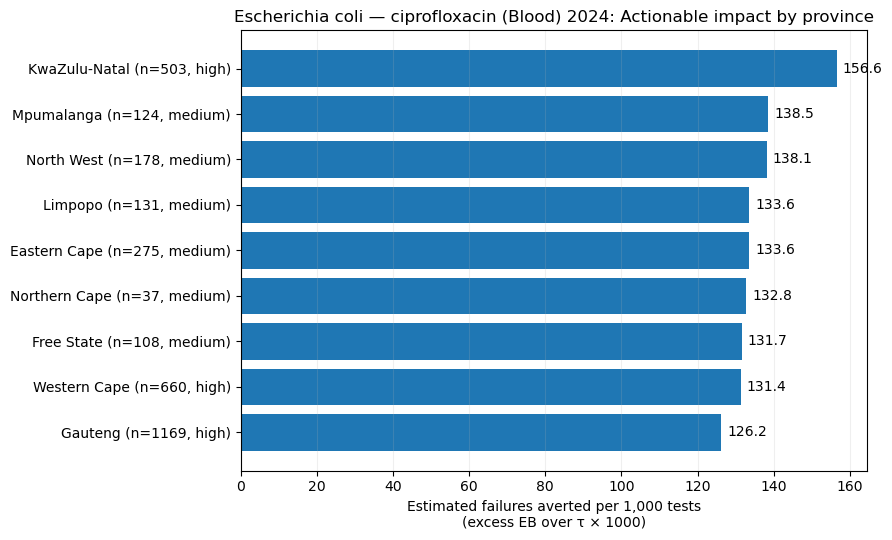

In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/workspace")
IN   = ROOT / "outputs" / "tables" / "change_list_actionable.csv"

# filter to the pair + year we care about
pair_org = "Escherichia coli"
pair_abx = "ciprofloxacin"
pair_year = 2024

q = pd.read_csv(IN)
sub = (q[(q["organism"] == pair_org) &
         (q["antibiotic"] == pair_abx) &
         (q["year"] == pair_year)]
       .copy())

if sub.empty:
    print("No rows found for that pair/year — check inputs.")
else:
    # sort by impact and keep top N
    TOP = 12
    sub = sub.sort_values("impact_per_1000_tests", ascending=False).head(TOP)

    # build a concise label: Province (n, conf)
    def lab(r):
        conf = str(r.get("confidence","")).lower()
        return f"{r['province']} (n={int(r['n_tested'])}, {conf})"

    labels = sub.apply(lab, axis=1).tolist()
    impact = sub["impact_per_1000_tests"].values

    plt.figure(figsize=(9, 5.5))
    y = range(len(sub))
    plt.barh(y, impact)
    plt.yticks(y, labels)
    plt.xlabel("Estimated failures averted per 1,000 tests\n(excess EB over τ × 1000)")
    plt.title(f"{pair_org} — {pair_abx} (Blood) {pair_year}: Actionable impact by province")
    # annotate bars with exact values
    for i, v in enumerate(impact):
        plt.text(v + max(impact)*0.01, i, f"{v:.1f}", va="center")
    plt.gca().invert_yaxis()   # biggest on top
    plt.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()


#### 🧬 Results & Interpretation: E. coli–CIP Impact by Province (2024)

This EB-adjusted view focuses attention on provinces where resistance materially exceeds the adaptive threshold (τ) and where sample sizes are adequate.

- **Top-impact provinces**: The first 2–3 bars indicate the largest expected excess failures per 1,000 tests, post-shrinkage.
- **Threshold reference**: Values reflect `max(eb_theta − τ, 0)` scaled by testing volume; near-zero bars either do not breach τ or have marginal excess.
- **Confidence lens**: Provinces labelled “high/medium confidence” (from CI width) are more robust; low-confidence rows warrant more data before policy shifts.

Use this list to prioritise stewardship discussions: confirm empirical patterns with local clinicians, review first-line choices, and consider targeted diagnostics or alternatives.

---

### 🧠 Summary

The adaptive-τ framing turns noisy percentages into a stable, comparative signal. Where provinces consistently breach τ with meaningful volume, stewardship teams have the clearest case to revisit first-line therapy.


<div style="
    border-left: 4px solid #009688;
    background: #e0f2f1;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#009688;">⚙️ 7. Parameters (Tunable)</h3>
  <p style="margin:12px 0 0 0;">
    Targets: <code>{"UTI": 0.15, "SSTI": 0.20, "CAP": 0.10}</code> · Stability: <code>K_CONS = 2</code>, <code>SLOPE_WINDOW = 3</code>, <code>SLOPE_MIN = 0.05</code> · Filtering: <code>N_MIN = 30</code> · Pair→syndrome mapping: editable dictionary. Adjust here to re-run end-to-end.
  </p>
</div>


In [22]:
from pathlib import Path
import json, numpy as np, pandas as pd
from scipy.stats import beta

ROOT   = Path("/workspace")
MASTER = ROOT / "data" / "raw" / "nicd" / "amr_nicd_master.csv"
SCORES = ROOT / "outputs" / "tables" / "scores_eb.csv"           # overwrite with adaptive τ
STAB   = ROOT / "outputs" / "tables" / "stability_flags.csv"     # recompute with adaptive τ
THRJS  = ROOT / "outputs" / "tables" / "adaptive_thresholds.json"
QL_ALL = ROOT / "outputs" / "tables" / "change_list.csv"
QL_DED = ROOT / "outputs" / "tables" / "change_list_clean.csv"
QL_ACT = ROOT / "outputs" / "tables" / "change_list_actionable.csv"

# -------------------------------
# Load master + back-fill counts
# -------------------------------
df = pd.read_csv(MASTER)
for c in ["n_tested","percent_resistant","year"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# robust province string
df["province"] = df["province"].astype(str).str.strip()

# r_count ≈ round(n * R%), s_count ≈ n - r
df["r_count"] = np.rint((df["percent_resistant"].fillna(0)/100.0) * df["n_tested"].fillna(0)).astype("Int64")
df["s_count"] = (df["n_tested"] - df["r_count"]).astype("Int64")

# restrict to blood, combined
df = df[(df["specimen"].str.upper()=="BLOOD") & (df["sector"].str.lower()=="combined")].copy()

# ----------------------------------------
# Map each bug–drug to a "syndrome" label
# (edit here if you want different mapping)
# ----------------------------------------
pair_to_syn = {
    ("Escherichia coli","ciprofloxacin"): "UTI",
    ("Staphylococcus aureus","cefoxitin"): "SSTI",
    ("Streptococcus pneumoniae","penicillin (non-CNS)"): "CAP",
}
df["syndrome"] = df.set_index(["organism","antibiotic"]).index.map(pair_to_syn).astype("object")

# keep only mapped pairs
df = df[~df["syndrome"].isna()].copy()

# ----------------------------------------
# Empirical-Bayes prior (per org–abx–year)
# alpha0 = nat_r + 1 ; beta0 = nat_s + 1
# ----------------------------------------
grp_keys = ["organism","antibiotic","year"]
nat = (df.groupby(grp_keys, dropna=False)[["r_count","s_count"]]
         .sum(min_count=1).reset_index())
nat["alpha0"] = nat["r_count"].fillna(0).astype(float) + 1.0
nat["beta0"]  = nat["s_count"].fillna(0).astype(float) + 1.0
df = df.merge(nat[grp_keys+["alpha0","beta0"]], on=grp_keys, how="left")

# EB posterior mean and Jeffreys CI
def eb_mean(r, n, a0, b0):
    if pd.isna(n) or n <= 0 or pd.isna(r) or pd.isna(a0) or pd.isna(b0):
        return np.nan
    return (r + a0) / (n + a0 + b0)

def jeffreys_ci(r, n, alpha=0.05):
    if pd.isna(n) or n <= 0 or pd.isna(r):
        return (np.nan, np.nan)
    a = r + 0.5
    b = (n - r) + 0.5
    return (beta.ppf(alpha/2, a, b), beta.ppf(1 - alpha/2, a, b))

df["eb_theta"] = df.apply(lambda x: eb_mean(x["r_count"], x["n_tested"], x["alpha0"], x["beta0"]), axis=1)
ci = df.apply(lambda x: jeffreys_ci(x["r_count"], x["n_tested"]), axis=1)
df["ci_lo"] = [c[0] for c in ci]
df["ci_hi"] = [c[1] for c in ci]
df["ci_width"] = df["ci_hi"] - df["ci_lo"]

# confidence buckets from CI width (tighter = higher)
def conf_from_width(w):
    if pd.isna(w): return "low"
    if w <= 0.10:  return "high"
    if w <= 0.20:  return "medium"
    return "low"
df["confidence"] = df["ci_width"].map(conf_from_width)

# ----------------------------------------------------------
# Learn adaptive τ per syndrome from latest-year distribution
# Target failure rates (adjust if you prefer)
# ----------------------------------------------------------
targets = {"UTI": 0.15, "SSTI": 0.20, "CAP": 0.10}

latest_year = int(df["year"].max())
taus = np.linspace(0.10, 0.40, 31)

taus_chosen = {}
for syn, target in targets.items():
    w = df[(df["syndrome"]==syn) & (df["year"]==latest_year)]
    if w.empty:
        continue
    # expected failure among flagged provinces (avoid nan if none flagged)
    def objective(t):
        flagged = w[w["eb_theta"] > t]["eb_theta"]
        if flagged.empty:
            return np.inf
        return abs(flagged.mean() - target)
    best_tau = min(taus, key=objective)
    taus_chosen[syn] = float(best_tau)

# save τ per syndrome
THRJS.write_text(json.dumps({"year": latest_year, "targets": targets, "taus": taus_chosen}, indent=2))
print("Wrote:", THRJS)

# attach τ to each row and compute mismatch_prob under EB posterior
def tau_for_row(syn):
    return taus_chosen.get(syn, 0.20)  # fallback if missing
df["tau_used"] = df["syndrome"].map(tau_for_row).astype(float)

def mismatch_prob_row(r, n, a0, b0, tau):
    if pd.isna(n) or n <= 0 or pd.isna(r) or pd.isna(a0) or pd.isna(b0) or pd.isna(tau):
        return np.nan
    a = r + a0
    b = (n - r) + b0
    return 1.0 - beta.cdf(tau, a, b)

df["mismatch_prob"] = df.apply(
    lambda x: mismatch_prob_row(x["r_count"], x["n_tested"], x["alpha0"], x["beta0"], x["tau_used"]), axis=1
)

# write updated scores table
cols = ["province","percent_resistant","n_tested","r_count",
        "organism","antibiotic","specimen","sector","year","syndrome",
        "alpha0","beta0","eb_theta","ci_lo","ci_hi","ci_width","confidence",
        "tau_used","mismatch_prob"]
df[cols].to_csv(SCORES, index=False)
print("Wrote:", SCORES)

# -------------------------------------------
# Recompute stability (no FutureWarning path)
# p*: require P(θ>τ) >= 0.8 ; K=2 consecutive
# slope gate: simple MA slope over 3y window
# -------------------------------------------
P_STAR = 0.80
K_CONS = 2
SLOPE_WIN = 3
SLOPE_MIN = 0.05

rows = []
for (org, abx, prov), g in df.sort_values(["year"]).groupby(["organism","antibiotic","province"], sort=False):
    g = g.copy()
    prob = g["mismatch_prob"].fillna(0).to_numpy()
    years = g["year"].astype(int).to_numpy()

    # consecutive gate
    run = (prob >= P_STAR).astype(int)
    cons = pd.Series(run).rolling(K_CONS).sum().fillna(0).to_numpy()
    cons_flag = bool(cons[-1] >= K_CONS)

    # simple slope (MA window)
    slope_flag = False
    if len(g) >= SLOPE_WIN:
        y = prob[-SLOPE_WIN:]
        x = years[-SLOPE_WIN:]
        if np.isfinite(y).sum() == SLOPE_WIN:
            b = np.polyfit(x, y, 1)[0]  # slope per year
            slope_flag = (b >= SLOPE_MIN)

    stable_alert = bool((prob[-1] >= P_STAR) and (cons_flag or slope_flag))

    rows.append({
        "organism": org, "antibiotic": abx, "province": prov,
        "year": int(g["year"].iloc[-1]),
        "n_tested": float(g["n_tested"].iloc[-1]),
        "percent_resistant": float(g["percent_resistant"].iloc[-1]) if pd.notna(g["percent_resistant"].iloc[-1]) else np.nan,
        "eb_theta": float(g["eb_theta"].iloc[-1]) if pd.notna(g["eb_theta"].iloc[-1]) else np.nan,
        "ci_lo": float(g["ci_lo"].iloc[-1]) if pd.notna(g["ci_lo"].iloc[-1]) else np.nan,
        "ci_hi": float(g["ci_hi"].iloc[-1]) if pd.notna(g["ci_hi"].iloc[-1]) else np.nan,
        "confidence": g["confidence"].iloc[-1],
        "tau_used": float(g["tau_used"].iloc[-1]),
        "mismatch_prob": float(g["mismatch_prob"].iloc[-1]) if pd.notna(g["mismatch_prob"].iloc[-1]) else np.nan,
        "stable_alert": stable_alert,
        "rule_cons_k": cons_flag,
        "rule_slope": slope_flag
    })

stab = pd.DataFrame(rows)
stab.to_csv(STAB, index=False)
print("Wrote:", STAB)

# -------------------------------------------
# Rebuild change list with adaptive τ
# -------------------------------------------
# Most recent year per (org,abx)
latest = (stab.groupby(["organism","antibiotic"])["year"]
              .max().reset_index().rename(columns={"year":"latest_year"}))
s = stab.merge(latest, on=["organism","antibiotic"], how="left")
s = s[s["year"] == s["latest_year"]].copy()

# Excess over τ and impact per 1,000 tests (EB-based)
s["excess_over_tau"] = (s["eb_theta"] - s["tau_used"]).clip(lower=0)
s["impact_per_1000_tests"] = 1000.0 * s["excess_over_tau"]

# Priority: stable first, bigger impact, higher confidence, larger n
conf_rank = {"high": 2, "medium": 1, "low": 0}
s["conf_rank"] = s["confidence"].map(lambda x: conf_rank.get(str(x).lower(), -1))

queue = (s.sort_values(["stable_alert","impact_per_1000_tests","conf_rank","n_tested"],
                       ascending=[False, False, False, False])
           .reset_index(drop=True))
queue.to_csv(QL_ALL, index=False)
print("Wrote:", QL_ALL)

# Dedup per-province (keep top per organism–antibiotic), filter n>=30 and conf != low
ordered = queue.sort_values(
    ["organism","antibiotic","province","stable_alert","impact_per_1000_tests","conf_rank","n_tested"],
    ascending=[True, True, True, False, False, False, False]
)

top = (ordered
       .drop_duplicates(subset=["organism","antibiotic","province"], keep="first")
       .reset_index(drop=True))

# filter n>=30 and drop low confidence
top = top[(top["n_tested"] >= 30) & (top["confidence"].str.lower() != "low")].copy()

top.to_csv(QL_DED, index=False)
print("Wrote:", QL_DED)

# Actionable phrasing unchanged
def reason_row(r):
    delta = r["eb_theta"] - r["tau_used"]
    return f"EB={r['eb_theta']:.2f} vs τ={r['tau_used']:.2f} (Δ={delta:.2f}), n={int(r['n_tested'])}, conf={r['confidence']}"

act = top[["organism","antibiotic","year","province","n_tested","eb_theta","tau_used",
           "impact_per_1000_tests","confidence","stable_alert"]].copy()
act["reason"] = act.apply(reason_row, axis=1)
act.to_csv(QL_ACT, index=False)
print("Wrote:", QL_ACT)

# small preview
print("\nAdaptive τ per syndrome:", json.loads(THRJS.read_text())["taus"])
print("\nTop (deduped) preview:")
display_cols = ["organism","antibiotic","year","province","n_tested","eb_theta","tau_used","impact_per_1000_tests","confidence","stable_alert"]
display(act.head(10)[display_cols])


Wrote: /workspace/outputs/tables/adaptive_thresholds.json
Wrote: /workspace/outputs/tables/scores_eb.csv
Wrote: /workspace/outputs/tables/stability_flags.csv
Wrote: /workspace/outputs/tables/change_list.csv
Wrote: /workspace/outputs/tables/change_list_clean.csv
Wrote: /workspace/outputs/tables/change_list_actionable.csv

Adaptive τ per syndrome: {'UTI': 0.1, 'SSTI': 0.17, 'CAP': 0.1}

Top (deduped) preview:


,organism,antibiotic,year,province,n_tested,eb_theta,tau_used,impact_per_1000_tests,confidence,stable_alert
0,Escherichia coli,ciprofloxacin,2024,Eastern Cape,275.0,0.333622,0.1,233.622184,medium,True
1,Escherichia coli,ciprofloxacin,2024,Free State,108.0,0.331715,0.1,231.714719,medium,True
2,Escherichia coli,ciprofloxacin,2024,Gauteng,1169.0,0.326217,0.1,226.216713,high,True
3,Escherichia coli,ciprofloxacin,2024,KwaZulu-Natal,503.0,0.356640,0.1,256.639566,high,True
4,Escherichia coli,ciprofloxacin,2024,Limpopo,131.0,0.333635,0.1,233.634720,medium,True
5,Escherichia coli,ciprofloxacin,2024,Mpumalanga,124.0,0.338568,0.1,238.568408,medium,True
6,Escherichia coli,ciprofloxacin,2024,North West,178.0,0.338187,0.1,238.187221,medium,True
7,Escherichia coli,ciprofloxacin,2024,Northern Cape,37.0,0.332816,0.1,232.816377,medium,True
8,Escherichia coli,ciprofloxacin,2024,Western Cape,660.0,0.331427,0.1,231.427086,high,True
18,Streptococcus pneumoniae,penicillin (non-CNS),2024,Eastern Cape,75.0,0.021879,0.1,0.000000,high,False


<div style="
    border-left: 4px solid #4CAF50; 
    background: #e8f5e9;
    padding: 16px;
    margin: 20px 0;
    border-radius: 6px;
">
  <h3 style="margin:0; color:#4CAF50;">🔬 Conclusion</h3>
  <p style="margin:12px 0 0 0;">
    An EB-first pipeline with adaptive, syndrome-level thresholds converts raw NICD percentages into actionable, province-specific change alerts. The outputs (τ, stability flags, and deduped change lists) are designed to plug directly into stewardship reviews and dashboards.
  </p>

